# LangGraph 最小验证 Notebook
---
目标：验证 LangGraph `StateGraph` 基础流转，建立 `GlobalState` 定义与各层节点骨架。

**不包含**：完整 LLM 推理、Primitive 调用、RoboDK 连接。  
**约定**：所有生产逻辑在 `SkiLib/` 中实现，此 Notebook 仅用于框架验证。

In [ ]:
# ── 依赖安装 ──────────────────────────────────────────────────────────────────
%pip install -q python-dotenv
%pip install -qU langchain-core langchain-ollama
%pip install -qU langgraph
%pip install -qU langchain-anthropic

In [1]:
# ── 导入与环境初始化 ───────────────────────────────────────────────────────────
import os
import getpass
import logging
from dotenv import load_dotenv

from langchain_ollama import ChatOllama
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_anthropic import ChatAnthropic

from langgraph.graph import StateGraph, START, END

# 从项目根目录 .env 加载 API Key 与追踪配置
load_dotenv()

# LangSmith 追踪（可选 — 在 .env 中设置 LANGSMITH_TRACING=true 启用）
if os.getenv("LANGSMITH_TRACING", "false").lower() == "true":
    if not os.getenv("LANGSMITH_API_KEY"):
        os.environ["LANGSMITH_API_KEY"] = getpass.getpass("Enter LangSmith API Key: ")
    if not os.getenv("LANGSMITH_PROJECT"):
        os.environ["LANGSMITH_PROJECT"] = getpass.getpass("Enter LangSmith Project name: ")

logging.basicConfig(level=logging.ERROR, force=True)
print("Environment loaded. LangSmith tracing:", os.getenv("LANGSMITH_TRACING", "false"))

Environment loaded. LangSmith tracing: false


In [2]:
LLM_TYPE = "claude"  # 可选 "claude" 或 "ollama"（本地）
# ── LLM 配置 ──────────────────────────────────────────────────────────────────
# 使用本地 Ollama 时修改 OLLAMA_MODEL_ID 切换模型
OLLAMA_MODEL_ID = os.getenv("OLLAMA_MODEL_ID", "qwen3:latest")
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")

if LLM_TYPE == "claude":
    llm = ChatAnthropic(
        model="claude-sonnet-4-6"
    )
else:
    llm = ChatOllama(
        model=OLLAMA_MODEL_ID,
        base_url=OLLAMA_BASE_URL,
        temperature=0,
    )

# 快速连通性检查
try:
    _ping = llm.invoke("Reply with one word: ready")
    print("LLM reachable:", _ping.content.strip()[:80])
except Exception as e:
    print(f"[WARN] LLM not reachable — nodes using llm will fail. ({e})")

LLM reachable: ready


## GlobalState
与 `CLAUDE.md` 中 `GlobalState` 规范保持一致。  
`robot_state` 此处用 `dict` 代替，生产版本从 `SkiLib.base` 导入 `RobotState`。

In [3]:
# ── GlobalState 定义 ──────────────────────────────────────────────────────────
from typing import TypedDict, Annotated, Optional
import operator


class GlobalState(TypedDict):
    # Layer-1：规划层输出
    todo_list: list[dict]           # Planner 生成 [{task_id, skill, params}, ...]
    # Layer-2：执行上下文
    current_task: dict              # 执行槽：{} = 空闲，{...} = 执行中或失败保留
    # 机器人运行时快照（此处用 dict 代替，生产类型：SkiLib.base.RobotState）
    robot_state: dict
    # 控制标志
    halt_flag: bool                 # True = 所有 R-skill 执行被锁定
    # Executor 写入结果；Context Flush 成功后清空
    last_result: Optional[dict]
    # 审计日志，由 Context Flush 写入；Annotated list 避免键覆盖
    execution_log: Annotated[list[str], operator.add]
    # LangGraph 消息总线
    messages: Annotated[list[BaseMessage], operator.add]


print("GlobalState keys:", list(GlobalState.__annotations__.keys()))

GlobalState keys: ['todo_list', 'current_task', 'robot_state', 'halt_flag', 'last_result', 'execution_log', 'messages']


## Supervisor Task-Skills
Supervisor 在 ReAct 循环中调用这些工具收集领域知识，直到**知识饱和**（LLM 不再调用工具）。

| 工具 | 作用 |
|------|------|
| `query_assembly_spec` | 按零件 ID 查询装配规范（目标位、所需工具等） |
| `list_available_targets` | 列出工作空间内所有符号目标位 |
| `list_available_tools` | 列出机器人可用末端执行器 |
| `request_human_intervention` | 无法消除歧义时触发 HILP，系统挂起 |

**约束**：所有工具只返回符号 ID（`Part_A`、`Slot_1`），不含坐标。

In [12]:
# ── Supervisor Task-Skills ────────────────────────────────────────────────────
# Supervisor 通过这些工具收集领域知识，所有返回值只含符号 ID，不含坐标。
# 生产版本：由真实 YAML 规范文件 + RoboDK 工作空间查询提供支撑。
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, ToolMessage


@tool
def query_assembly_spec(part_id: str) -> str:
    """Query the assembly specification for a given part ID (e.g. Part_A)."""
    specs = {
        "Part_A": (
            "Part_A: M10 bolt. "
            "Pick target: Pick_Zone_A. "
            "Place target: Slot_1 on Tray_1. "
            "Required tool: Tool_Gripper. "
            "Pre-condition: gripper must be empty."
        ),
        "Part_B": (
            "Part_B: M10 washer. "
            "Pick target: Pick_Zone_B. "
            "Place target: Slot_2 on Tray_1. "
            "Required tool: Tool_Suction."
        ),
    }
    return specs.get(
        part_id,
        f"No spec found for '{part_id}'. Verify part ID or call request_human_intervention.",
    )


@tool
def list_available_targets() -> str:
    """List all available symbolic target positions in the workspace."""
    return (
        "Symbolic targets: Home, Pick_Zone_A, Pick_Zone_B, "
        "Slot_1 (on Tray_1), Slot_2 (on Tray_1)"
    )


@tool
def list_available_tools() -> str:
    """List all available robot end-effectors."""
    return "Available tools: Tool_Gripper (parallel jaw), Tool_Suction (vacuum cup)"


@tool
def request_human_intervention(reason: str) -> str:
    """
    Request human intervention when the instruction is ambiguous
    or beyond the robot's capability boundary. This halts the system.
    """
    return f"[HILP] Human intervention requested — reason: {reason}"


SUPERVISOR_TOOLS = [
    query_assembly_spec,
    list_available_targets,
    list_available_tools,
    request_human_intervention,
]
SUPERVISOR_TOOL_MAP = {t.name: t for t in SUPERVISOR_TOOLS}

print("Supervisor tools registered:", [t.name for t in SUPERVISOR_TOOLS])

Supervisor tools registered: ['query_assembly_spec', 'list_available_targets', 'list_available_tools', 'request_human_intervention']


## Node Implementations

各节点实现状态：

| 节点 | 层 | 状态 | 说明 |
|------|----|------|------|
| `supervisor` | Layer-1 | **已实现** | ReAct loop：调用 task-skills 迭代至知识饱和，LLM 停止调用工具即退出 |
| `planner` | Layer-1 | STUB | 生成硬编码 `todo_list`；生产版需结构化输出 + Pydantic 校验 + retry |
| `dispatcher` | Layer-2 | **已实现** | 纯代码，仅在槽空（`current_task=={}`）时 pop 任务，槽非空时跳过 |
| `executor` | Layer-2 | STUB | 模拟执行成功，写入 `last_result`；生产版动态加载 SkiLib Skill |
| `context_flush` | Layer-2 | **已实现** | 成功：清槽 + 清 last_result；失败：保留任务 + 设 halt_flag |

In [9]:
# ── 节点：Supervisor ──────────────────────────────────────────────────────────
# 职责：通过 ReAct 循环调用 task-skills，消除所有知识盲区后移交 Planner。
# 循环不变量：持续迭代直到 LLM 不再发起 tool_call（知识饱和）或达到 MAX_ITER。
# 约束：只输出符号 ID；禁止计算坐标；禁止调用任何硬件 API。

_SUPERVISOR_SYSTEM_PROMPT = """\
You are the Supervisor of an industrial robot assembly system.

Your role: resolve ALL ambiguities in the assembly instruction before handing off to the Planner.
Use the provided tools to gather domain knowledge (part specs, available targets, tools).

STRICT RULES:
- Output ONLY symbolic IDs (e.g. Part_A, Pick_Zone_A, Slot_1, Tool_Gripper). NEVER output raw coordinates (x,y,z).
- NEVER call hardware APIs directly.
- Keep calling tools until you reach knowledge saturation: you know what parts,
  which pick/place targets, which tools, and a clear execution order.
- If a genuine ambiguity cannot be resolved with tools, call request_human_intervention.

When knowledge is saturated, output a summary in this exact format and stop calling tools:
KNOWLEDGE SATURATED:
- Parts       : <symbolic IDs>
- Pick targets: <symbolic IDs>
- Place targets: <symbolic IDs>
- Tools       : <symbolic IDs>
- Order       : <brief description>
"""

def supervisor(state: GlobalState) -> dict:
    """
    ReAct loop: LLM calls task-skills iteratively until knowledge saturation.
    Terminates when LLM response contains no tool_calls, or MAX_ITER is reached.
    """
    llm_with_tools = llm.bind_tools(SUPERVISOR_TOOLS)

    # 构建循环上下文：系统提示前置，已有对话追加
    loop_msgs = [SystemMessage(content=_SUPERVISOR_SYSTEM_PROMPT)] + list(state["messages"])
    initial_len = len(loop_msgs)   # 用于最后切片，只返回本次循环新产生的消息

    MAX_ITER = 6
    for iteration in range(MAX_ITER):
        response = llm_with_tools.invoke(loop_msgs)
        loop_msgs.append(response)

        n_calls = len(response.tool_calls)
        print(f"[supervisor] iter={iteration + 1}, tool_calls={n_calls}")

        if not response.tool_calls:
            # 没有 tool_call → LLM 判断知识已饱和
            print("[supervisor] Knowledge saturation reached.")
            break

        # 执行每个 tool_call，将 ToolMessage 结果喂回上下文
        for tc in response.tool_calls:
            fn = SUPERVISOR_TOOL_MAP.get(tc["name"])
            result = fn.invoke(tc["args"]) if fn else f"Unknown tool: {tc['name']}"
            print(f"  ↳ {tc['name']}({tc['args']}) → {str(result)[:100]}")
            loop_msgs.append(ToolMessage(content=str(result), tool_call_id=tc["id"]))
    else:
        print(f"[supervisor] 达到最大迭代次数 ({MAX_ITER})，知识仍未饱和，请检查指令。")

    # 只返回本次循环新产生的消息，不含初始上下文
    new_msgs = loop_msgs[initial_len:]
    return {"messages": new_msgs}


# ── 节点：Planner ─────────────────────────────────────────────────────────────
# 职责：通过强制结构化输出生成 todo_list JSON 任务队列。
# 约束：输出必须是合法 JSON；生产版需加 Pydantic 校验 + retry 逻辑。
# TODO：替换为真实 LLM 结构化输出 + Pydantic schema + retry
def planner(state: GlobalState) -> dict:
    print("[planner] Generating task plan...")
    todo = [
        {"task_id": "t1", "skill": "MoveJ",       "params": {"target": "Home"}},
        {"task_id": "t2", "skill": "PickAndPlace", "params": {"pick": "Pick_Zone_A", "place": "Slot_1"}},
        {"task_id": "t3", "skill": "MoveJ",       "params": {"target": "Home"}},
    ]
    return {
        "todo_list": todo,
        "messages":  [AIMessage(content=f"[Planner] {len(todo)} tasks queued")],
    }


# ── 节点：Dispatcher（纯代码，无 LLM）────────────────────────────────────────
# 职责：填充执行槽 — 仅当 current_task == {} 时 pop todo_list[0]；槽非空时跳过。
# 约束：100% 确定性；禁止调用任何 LLM。
def dispatcher(state: GlobalState) -> dict:
    if state.get("current_task"):
        # 槽已占用（执行中或失败保留），不覆盖
        print(f"[dispatcher] 槽已占用：{state['current_task'].get('task_id')} — 跳过。")
        return {}
    todo = list(state.get("todo_list", []))
    if not todo:
        print("[dispatcher] todo_list 为空，无任务可调度。")
        return {}
    task = todo.pop(0)
    print(f"[dispatcher] Dispatching: {task}")
    return {"current_task": task, "todo_list": todo}


# ── 节点：Executor ────────────────────────────────────────────────────────────
# 职责：执行 current_task 对应的 Skill，将结果写入 last_result。
# 约束：所有 R-skill 必须受 @require_robot_active 保护；此处检查 halt_flag。
# TODO：替换为动态 Skill 加载器 + SkiLib.base.SkillResult
def executor(state: GlobalState) -> dict:
    task = state.get("current_task", {})
    if not task:
        return {
            "execution_log": ["[executor] 无任务，跳过。"],
            "last_result": {"success": True},
        }
    if state.get("halt_flag"):
        return {
            "execution_log": [f"[executor] 已挂起 — 跳过 {task.get('task_id')}"],
            "last_result": {"success": False, "error_type": "ROBOT_INACTIVE"},
        }
    print(f"[executor] Running: {task['skill']}({task['params']})")
    # STUB：不触碰机器人，模拟执行成功
    return {
        "execution_log": [f"[executor] {task['task_id']} {task['skill']} -> SUCCESS (stub)"],
        "last_result": {"success": True},
    }


# ── 节点：Context Flush（纯代码）──────────────────────────────────────────────
# 职责：成功时 — 清空 current_task（腾出槽位）并清空 last_result。
#       失败时 — 设置 halt_flag；current_task 与 todo_list 保持不变，
#                resume 后直接重试同一任务。
# TODO：Executor 启用真实 tool call 后，补充 RemoveMessage 清扫逻辑
def context_flush(state: GlobalState) -> dict:
    task_id = state.get("current_task", {}).get("task_id", "?")
    last_result = state.get("last_result") or {}

    if last_result.get("success"):
        entry = f"[context_flush] Task {task_id} committed."
        print(entry)
        return {
            "current_task": {},    # 清空槽位，Dispatcher 下次迭代填入新任务
            "last_result":  None,
            "execution_log": [entry],
        }
    else:
        entry = f"[context_flush] Task {task_id} FAILED — halting, task retained in queue."
        print(entry)
        return {
            "halt_flag":     True,  # 锁定系统；current_task 保留，resume 后重试
            "execution_log": [entry],
        }


print("All nodes defined.")

All nodes defined.


## Graph Construction
流转顺序：`START → supervisor → planner → [dispatcher → executor → context_flush] × N → END`

`should_continue` 路由逻辑（优先级从高到低）：

| 条件 | 路由 | 说明 |
|------|------|------|
| `halt_flag=True` | `halt → END` | 执行失败或人工介入请求；`current_task` 保留，resume 后重试 |
| `todo_list` 非空 | `continue → dispatcher` | 槽已清空，取下一个任务 |
| 其他 | `done → END` | 队列清空，正常结束 |

**`current_task` 作为执行槽的状态语义：**
- `{}` → 槽空闲，Dispatcher 负责填充
- `{...}` → 任务在执行中（或失败保留），Dispatcher 跳过不覆盖

In [10]:
# ── 图构建 ────────────────────────────────────────────────────────────────────

def should_continue(state: GlobalState) -> str:
    """context_flush 之后的路由条件。优先级：halt > continue > done。"""
    if state.get("halt_flag"):
        return "halt"
    if state.get("todo_list"):
        return "continue"
    return "done"


builder = StateGraph(GlobalState)

builder.add_node("supervisor",    supervisor)
builder.add_node("planner",       planner)
builder.add_node("dispatcher",    dispatcher)
builder.add_node("executor",      executor)
builder.add_node("context_flush", context_flush)

# Layer-1：线性流转
builder.add_edge(START,        "supervisor")
builder.add_edge("supervisor", "planner")
builder.add_edge("planner",    "dispatcher")

# Layer-2：执行循环
builder.add_edge("dispatcher",   "executor")
builder.add_edge("executor",     "context_flush")
builder.add_conditional_edges(
    "context_flush",
    should_continue,
    {
        "continue": "dispatcher",  # 槽已清空，取下一个任务
        "done":     END,           # 队列清空，正常结束
        "halt":     END,           # halt_flag 已设置，等待人工介入
    },
)

graph = builder.compile()
print("Graph compiled.")

Graph compiled.


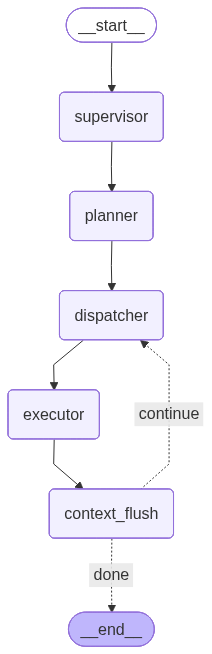

In [11]:
# 可选：可视化图结构（需要 graphviz）
try:
    from IPython.display import Image
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Visualization skipped:", e)
    print(graph.get_graph().draw_mermaid())

## Test Run

In [13]:
# ── 测试用例 1：正常指令 — Supervisor 应达到知识饱和 ────────────────────────────
initial_state: GlobalState = {
    "messages":      [HumanMessage(content="将 Part_A 装入 Tray_1")],
    "todo_list":     [],
    "current_task":  {},
    "robot_state":   {"joints": None, "pose": None, "gripper_state": "UNKNOWN"},
    "halt_flag":     False,
    "last_result":   None,
    "execution_log": [],
}

print("=" * 60)
print("TEST 1: Normal instruction")
print("=" * 60)
final_state = graph.invoke(initial_state)
print("=" * 60)
print("\nExecution log:")
for entry in final_state["execution_log"]:
    print(" ", entry)
print("Remaining todo_list:", final_state["todo_list"])
print("halt_flag:          ", final_state["halt_flag"])

# 打印 Supervisor 的推理轨迹（循环内产生的消息）
print("\n── Supervisor 推理轨迹 ─────────────────────────────────")
for msg in final_state["messages"]:
    role = type(msg).__name__
    content_preview = str(msg.content)[:200].replace("\n", " ")
    tool_calls = getattr(msg, "tool_calls", [])
    if tool_calls:
        calls = ", ".join(f"{tc['name']}({tc['args']})" for tc in tool_calls)
        print(f"  [{role}] → tool_calls: {calls}")
    else:
        print(f"  [{role}] {content_preview}")

TEST 1: Normal instruction
[supervisor] iter=1, tool_calls=3
  ↳ query_assembly_spec({'part_id': 'Part_A'}) → Part_A: M10 bolt. Pick target: Pick_Zone_A. Place target: Slot_1 on Tray_1. Required tool: Tool_Grip
  ↳ list_available_targets({}) → Symbolic targets: Home, Pick_Zone_A, Pick_Zone_B, Slot_1 (on Tray_1), Slot_2 (on Tray_1)
  ↳ list_available_tools({}) → Available tools: Tool_Gripper (parallel jaw), Tool_Suction (vacuum cup)
[supervisor] iter=2, tool_calls=0
[supervisor] Knowledge saturation reached.
[planner] Generating task plan...
[dispatcher] Dispatching: {'task_id': 't1', 'skill': 'MoveJ', 'params': {'target': 'Home'}}
[executor] Running: MoveJ({'target': 'Home'})
[context_flush] Task t1 committed.
[dispatcher] Dispatching: {'task_id': 't2', 'skill': 'PickAndPlace', 'params': {'pick': 'Pick_Zone_A', 'place': 'Slot_1'}}
[executor] Running: PickAndPlace({'pick': 'Pick_Zone_A', 'place': 'Slot_1'})
[context_flush] Task t2 committed.
[dispatcher] Dispatching: {'task_id': 't3', '

In [14]:
# ── 测试用例 2：歧义指令 — Supervisor 应调用 request_human_intervention ────────
ambiguous_state: GlobalState = {
    "messages":      [HumanMessage(content="把那个零件放好")],   # 无零件 ID，无目标位
    "todo_list":     [],
    "current_task":  {},
    "robot_state":   {"joints": None, "pose": None, "gripper_state": "UNKNOWN"},
    "halt_flag":     False,
    "last_result":   None,
    "execution_log": [],
}

print("=" * 60)
print("TEST 2: Ambiguous instruction (expect HILP)")
print("=" * 60)
final_ambiguous = graph.invoke(ambiguous_state)
print("=" * 60)
print("halt_flag:", final_ambiguous["halt_flag"])

print("\n── Supervisor 推理轨迹 ─────────────────────────────────")
for msg in final_ambiguous["messages"]:
    role = type(msg).__name__
    content_preview = str(msg.content)[:200].replace("\n", " ")
    tool_calls = getattr(msg, "tool_calls", [])
    if tool_calls:
        calls = ", ".join(f"{tc['name']}({tc['args']})" for tc in tool_calls)
        print(f"  [{role}] → tool_calls: {calls}")
    else:
        print(f"  [{role}] {content_preview}")

TEST 2: Ambiguous instruction (expect HILP)
[supervisor] iter=1, tool_calls=2
  ↳ list_available_targets({}) → Symbolic targets: Home, Pick_Zone_A, Pick_Zone_B, Slot_1 (on Tray_1), Slot_2 (on Tray_1)
  ↳ list_available_tools({}) → Available tools: Tool_Gripper (parallel jaw), Tool_Suction (vacuum cup)
[supervisor] iter=2, tool_calls=2
  ↳ query_assembly_spec({'part_id': 'Part_A'}) → Part_A: M10 bolt. Pick target: Pick_Zone_A. Place target: Slot_1 on Tray_1. Required tool: Tool_Grip
  ↳ query_assembly_spec({'part_id': 'Part_B'}) → Part_B: M10 washer. Pick target: Pick_Zone_B. Place target: Slot_2 on Tray_1. Required tool: Tool_Su
[supervisor] iter=3, tool_calls=1
  ↳ request_human_intervention({'reason': '指令"把那个零件放好"中"那个零件"指代不明。当前工作区存在两个已知零件：Part_A（M10螺栓，位于 Pick_Zone_A，目标位置 Slot_1）和 Part_B（M10垫片，位于 Pick_Zone_B，目标位置 Slot_2）。无法通过工具推断用户意图，需人工明确指定要操作的零件 ID。'}) → [HILP] Human intervention requested — reason: 指令"把那个零件放好"中"那个零件"指代不明。当前工作区存在两个已知零件：Part_A（M10螺栓，位于 P
[supervisor] iter=4, tool_cal